## Decision Tree Vs Random Forest

### Try with Classification Problem

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

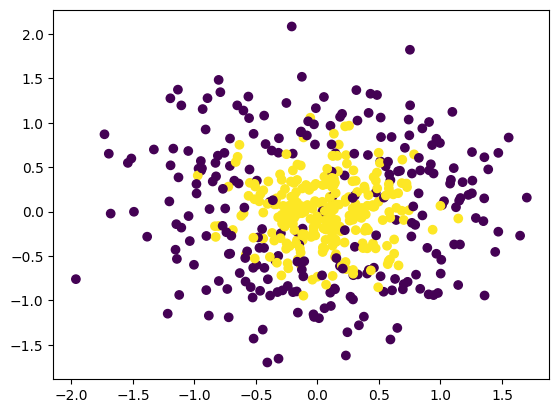

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

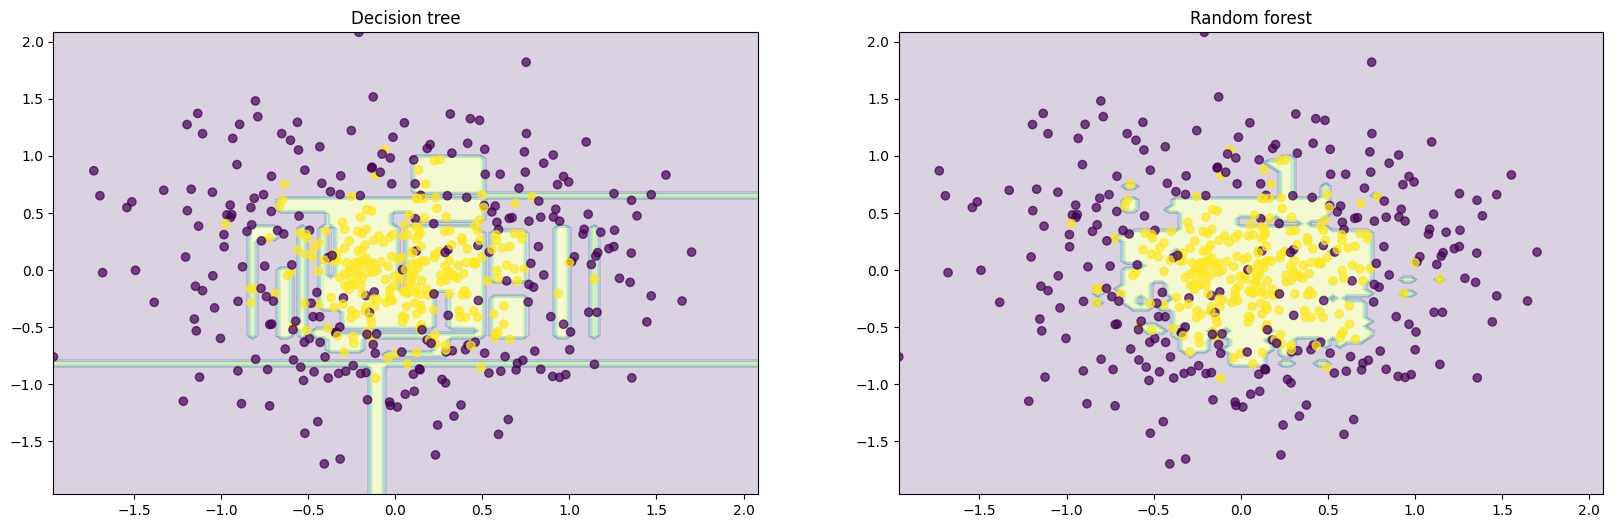

In [ ]:
plt.figure(figsize=(20, 6))

# Decision Tree Plot
plt.subplot(1, 2, 1)
y_hat_dtree = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat_dtree = y_hat_dtree.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat_dtree, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")

# Random Forest Plot
plt.subplot(1, 2, 2)
y_hat_rf = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat_rf = y_hat_rf.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat_rf, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")

plt.show()

### Try with Regression Problem

In [ ]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

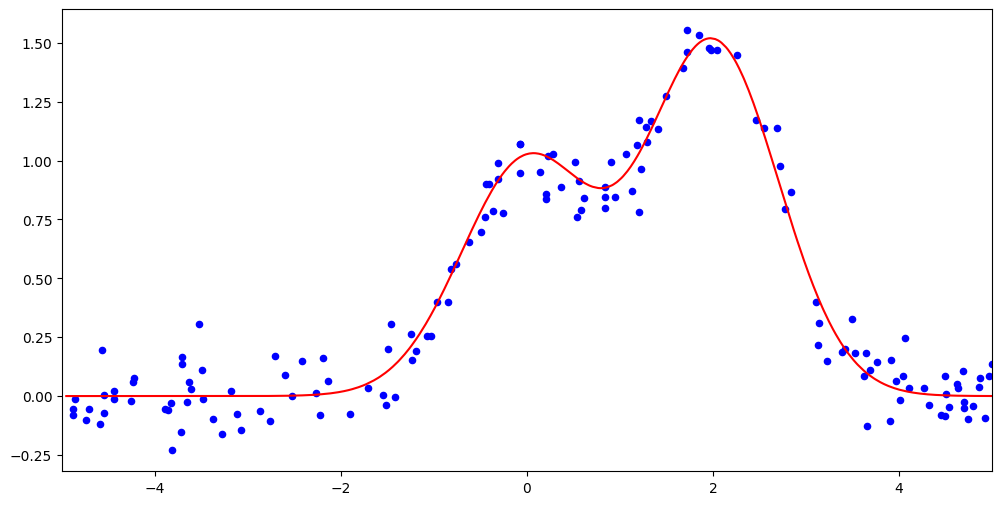

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

Text(0.5, 1.0, 'Decision tree, MSE = 18.67')

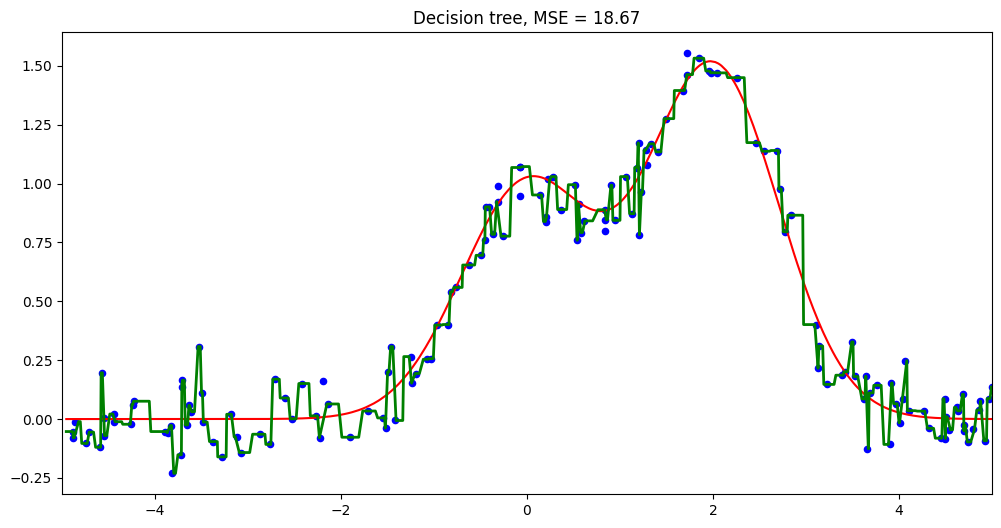

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100)
rfr.fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

Text(0.5, 1.0, 'Random forest, MSE = 14.66')

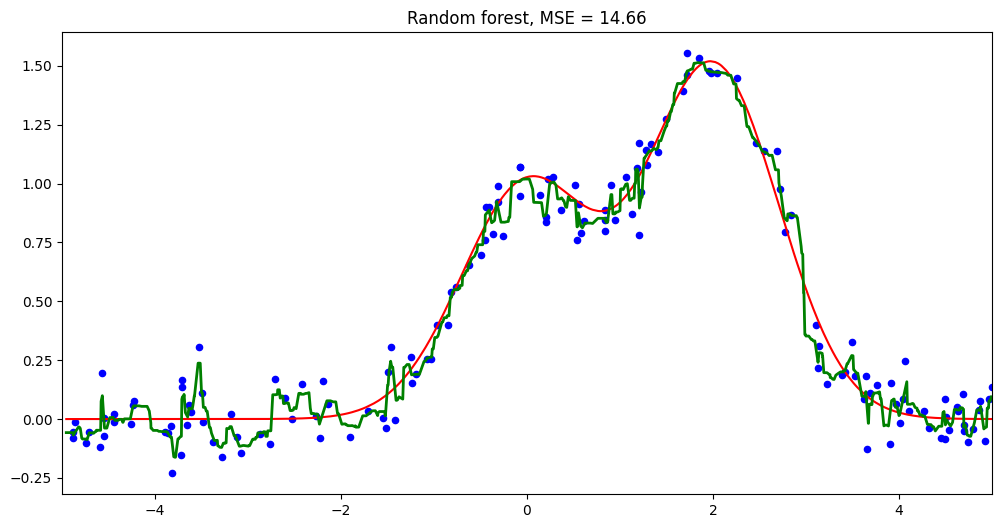

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))

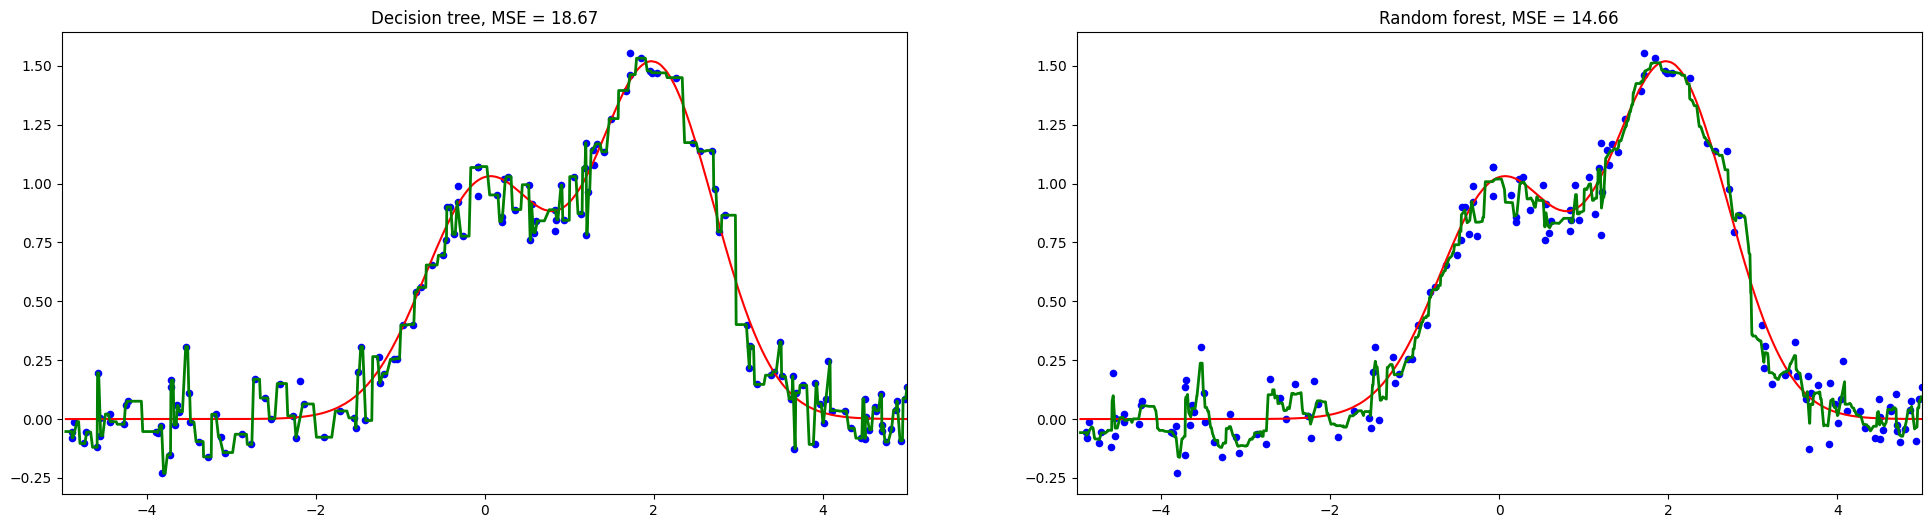

In [ ]:
plt.figure(figsize=(24, 6))

# Decision Tree Regression Plot
plt.subplot(1, 2, 1)
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" % np.sum((y_test - d_predict) ** 2))

# Random Forest Regression Plot
plt.subplot(1, 2, 2)
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))

plt.show()

## Bagging Vs Random Forest

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=5,
                           n_informative=2, n_redundant=0,
                           random_state=48, shuffle=False)
#X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [ ]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.390683,-1.848499,-0.521345,0.005217,-0.562210,0
1,-1.688328,-0.955030,2.269946,0.730295,-2.063558,0
2,-1.684613,-0.707638,0.030107,1.572636,-0.500165,0
3,-1.535501,-1.784075,-1.267572,-0.476979,0.089585,0
4,-0.671858,-0.310306,0.384039,0.180294,-0.501060,0


In [ ]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(n_estimators=100,max_features=2)
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2, n_estimators=100)

[Text(0.5454545454545454, 0.9285714285714286, 'x[1] <= -0.001\ngini = 0.497\nsamples = 68\nvalue = [46, 54]'),
 Text(0.2727272727272727, 0.7857142857142857, 'x[1] <= -2.964\ngini = 0.12\nsamples = 36\nvalue = [44.0, 3.0]'),
 Text(0.40909090909090906, 0.8571428571428572, 'True  '),
 Text(0.18181818181818182, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.6428571428571429, 'x[0] <= -0.708\ngini = 0.083\nsamples = 35\nvalue = [44, 2]'),
 Text(0.2727272727272727, 0.5, 'x[0] <= -0.903\ngini = 0.26\nsamples = 10\nvalue = [11, 2]'),
 Text(0.18181818181818182, 0.35714285714285715, 'x[1] <= -0.775\ngini = 0.153\nsamples = 9\nvalue = [11, 1]'),
 Text(0.09090909090909091, 0.21428571428571427, 'gini = 0.0\nsamples = 6\nvalue = [9, 0]'),
 Text(0.2727272727272727, 0.21428571428571427, 'x[0] <= -1.406\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.18181818181818182, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3636363636

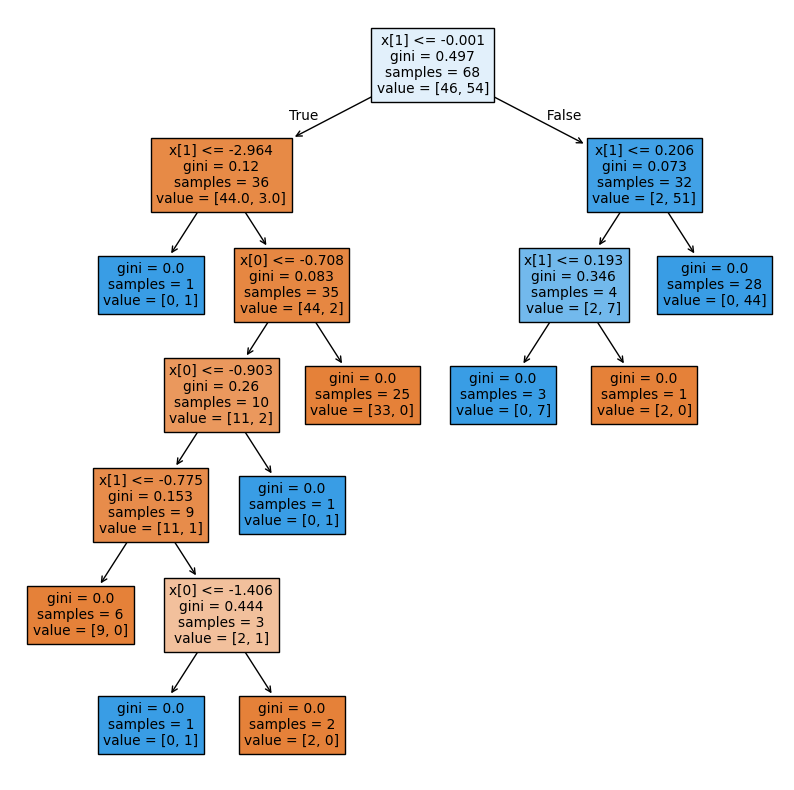

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(bag.estimators_[0],filled=True)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier()

[Text(0.6, 0.9285714285714286, 'x[3] <= 1.397\ngini = 0.487\nsamples = 64\nvalue = [42.0, 58.0]'),
 Text(0.5, 0.7857142857142857, 'x[1] <= -0.065\ngini = 0.469\nsamples = 58\nvalue = [35, 58]'),
 Text(0.55, 0.8571428571428572, 'True  '),
 Text(0.2, 0.6428571428571429, 'x[1] <= -2.77\ngini = 0.229\nsamples = 26\nvalue = [33, 5]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 2]'),
 Text(0.3, 0.5, 'x[0] <= 1.614\ngini = 0.153\nsamples = 25\nvalue = [33, 3]'),
 Text(0.2, 0.35714285714285715, 'gini = 0.0\nsamples = 23\nvalue = [33, 0]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 3]'),
 Text(0.8, 0.6428571428571429, 'x[1] <= 0.477\ngini = 0.07\nsamples = 32\nvalue = [2, 53]'),
 Text(0.7, 0.5, 'x[1] <= 0.338\ngini = 0.219\nsamples = 9\nvalue = [2, 14]'),
 Text(0.6, 0.35714285714285715, 'x[1] <= 0.196\ngini = 0.124\nsamples = 8\nvalue = [1, 14]'),
 Text(0.5, 0.21428571428571427, 'gini = 0.0\nsamples = 4\nvalue = [0, 8]'),
 Text(0.7, 0.21428571428571427, 'x

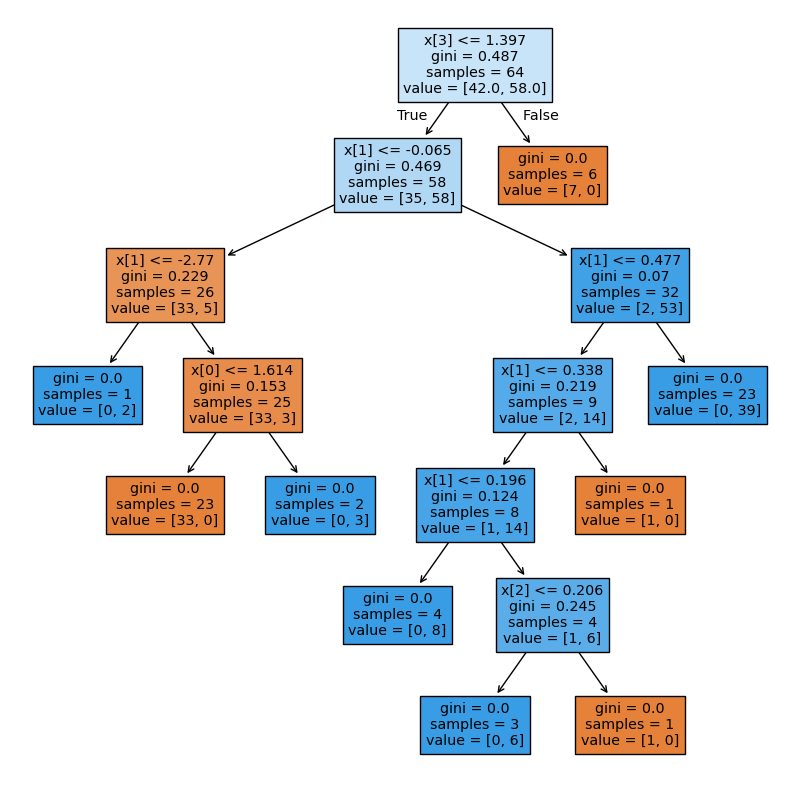

In [ ]:
plt.figure(figsize=(10,10))
plot_tree(rf.estimators_[0],filled=True)

## Hyperparameter Tuning Random Forest

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.3,random_state=42)

In [ ]:
print(X_train.shape,X_test.shape)

(212, 13) (91, 13)


In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7802197802197802

In [ ]:
rf = RandomForestClassifier(max_samples=0.75)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8131868131868132

In [ ]:
rf = RandomForestClassifier(max_depth=5)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8241758241758241

In [ ]:
rf = RandomForestClassifier(min_samples_split=5)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8241758241758241

In [ ]:
rf = RandomForestClassifier(min_samples_leaf=5)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8241758241758241

In [ ]:
rf = RandomForestClassifier(max_leaf_nodes=5)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8241758241758241

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8131868131868132

### Try with GridSearch CV

In [ ]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,False]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]

param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [ ]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier()
rf_grid = GridSearchCV(estimator = rf,
                       param_grid = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [ ]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False], 'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [ ]:
rf_grid.best_params_

{'bootstrap': True,
 'max_depth': 2,
 'max_features': 0.2,
 'max_samples': 1.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 60}

In [ ]:
rf_grid.best_score_

np.float64(0.858361018826135)

### Try with RandomSearch CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier()
rf_random = RandomizedSearchCV(estimator = rf,
                       param_distributions = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [ ]:
rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [ ]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_samples': 0.5,
 'max_features': 0.2,
 'max_depth': None,
 'bootstrap': True}

In [ ]:
rf_random.best_score_

np.float64(0.8299003322259135)

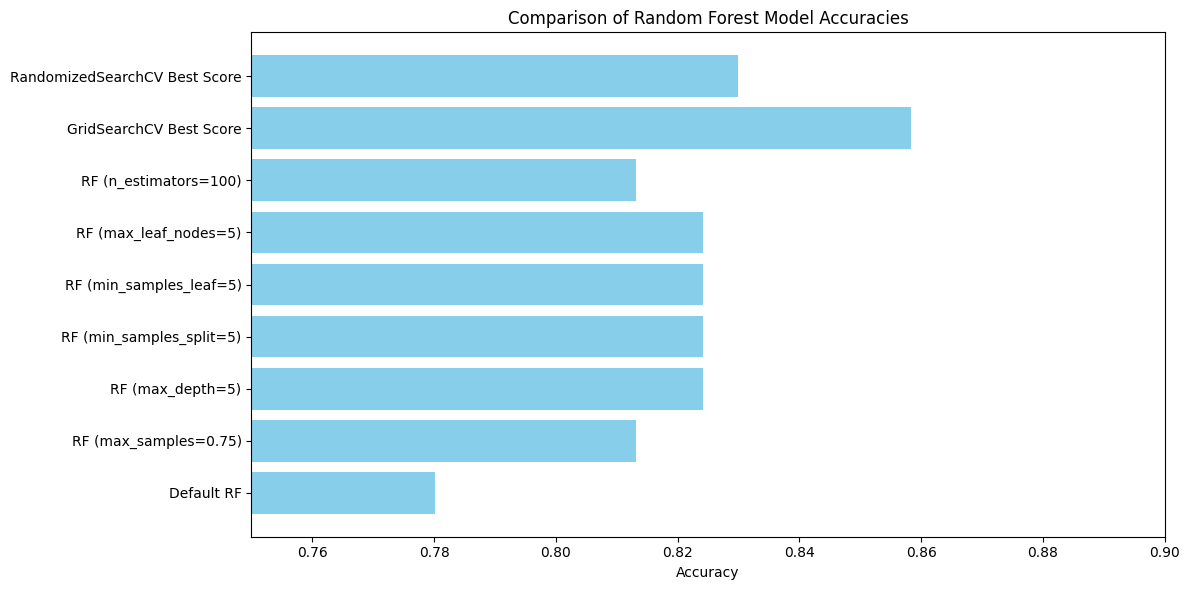

In [ ]:
import matplotlib.pyplot as plt

accuracy_labels = [
    "Default RF",
    "RF (max_samples=0.75)",
    "RF (max_depth=5)",
    "RF (min_samples_split=5)",
    "RF (min_samples_leaf=5)",
    "RF (max_leaf_nodes=5)",
    "RF (n_estimators=100)",
    "GridSearchCV Best Score",
    "RandomizedSearchCV Best Score"
]

accuracy_scores = [
    0.7802197802197802, # Default RF
    0.8131868131868132, # RF (max_samples=0.75)
    0.8241758241758241, # RF (max_depth=5)
    0.8241758241758241, # RF (min_samples_split=5)
    0.8241758241758241, # RF (min_samples_leaf=5)
    0.8241758241758241, # RF (max_leaf_nodes=5)
    0.8131868131868132, # RF (n_estimators=100)
    0.858361018826135,  # GridSearchCV Best Score
    0.8299003322259135  # RandomizedSearchCV Best Score
]

plt.figure(figsize=(12, 6))
plt.barh(accuracy_labels, accuracy_scores, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Comparison of Random Forest Model Accuracies')
plt.xlim(0.75, 0.9) # Adjust x-axis limits for better visualization of differences
plt.tight_layout()
plt.show()


## Out of Bag Score

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.3,random_state=42)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_samples=0.75, max_depth=5, oob_score=True)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8131868131868132

In [ ]:
rf.oob_score_

0.8349056603773585